In [1]:
import pandas as pd # 以pd别名导入Python数据分析模块
import re # 导入正则表达式模块，可进行模式匹配、搜索和替换
import numpy as np # 导入数值计算模块

import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
plt.rcParams['font.sans-serif'] = ['KaiTi']  #指定默认字体 SimHei黑体
plt.rcParams['axes.unicode_minus'] = False   #解决保存图像是负号'
import jieba
stop_list  = pd.read_csv("./edited_stopwords.txt",index_col=False,quoting=3,sep="\t",names=['stopword'], encoding='utf-8')

# STEP 1 合并评价与追评

In [3]:
reviews = pd.read_excel('./review/reviews.xlsx')# 导入平板电脑评论数据
reviews.head()

,商品名称,评价星级,评价内容,追评内容
0,iPad 10,star3,包装脏\n别的都没事服务也挺好,NaN
1,iPad 10,star3,看着用着应该不错，用用看呗,NaN
2,iPad 10,star3,还是比较满意吧，就是质量希望多多把关,NaN
3,iPad 10,star3,还可以吧，追剧时候有一点点卡，还在摸索中,NaN
4,iPad 10,star3,比较耗电，掉电很快！,NaN


In [4]:
reviews["追评内容"] = reviews["追评内容"].fillna('') # 将数值型NaN转为字符型
reviews["评论"] = reviews[["评价内容","追评内容"]].apply("\n".join, axis=1) # 合并评价与追评为评论
reviews.head()

,商品名称,评价星级,评价内容,追评内容,评论
0,iPad 10,star3,包装脏\n别的都没事服务也挺好,,包装脏\n别的都没事服务也挺好\n
1,iPad 10,star3,看着用着应该不错，用用看呗,,看着用着应该不错，用用看呗\n
2,iPad 10,star3,还是比较满意吧，就是质量希望多多把关,,还是比较满意吧，就是质量希望多多把关\n
3,iPad 10,star3,还可以吧，追剧时候有一点点卡，还在摸索中,,还可以吧，追剧时候有一点点卡，还在摸索中\n
4,iPad 10,star3,比较耗电，掉电很快！,,比较耗电，掉电很快！\n


In [5]:
reviews.drop(["评价内容","追评内容"], axis=1, inplace=True) # 删除评价内容、追评内容列，只保留评论列
reviews.head()

,商品名称,评价星级,评论
0,iPad 10,star3,包装脏\n别的都没事服务也挺好\n
1,iPad 10,star3,看着用着应该不错，用用看呗\n
2,iPad 10,star3,还是比较满意吧，就是质量希望多多把关\n
3,iPad 10,star3,还可以吧，追剧时候有一点点卡，还在摸索中\n
4,iPad 10,star3,比较耗电，掉电很快！\n


# STEP 2 评论去重

In [6]:
reviews["评论"].drop_duplicates(inplace=True) # drop_duplicates()去重函数
reviews.head()

,商品名称,评价星级,评论
0,iPad 10,star3,包装脏\n别的都没事服务也挺好\n
1,iPad 10,star3,看着用着应该不错，用用看呗\n
2,iPad 10,star3,还是比较满意吧，就是质量希望多多把关\n
3,iPad 10,star3,还可以吧，追剧时候有一点点卡，还在摸索中\n
4,iPad 10,star3,比较耗电，掉电很快！\n


In [8]:
# 数据转换
# reviews.loc[reviews["评价星级"] == "star5", "评价星级"] = "pos"
# reviews.loc[reviews["评价星级"] == "star4", "评价星级"] = "pos"
# reviews.loc[reviews["评价星级"] == "star3", "评价星级"] = "neg"
# reviews.loc[reviews["评价星级"] == "star2", "评价星级"] = "neg"
# reviews.loc[reviews["评价星级"] == "star1", "评价星级"] = "neg"

In [9]:
reviews.to_excel('./review/reviews_drdu.xlsx', index = False)

# STEP 3 SnowNLP情感标注

# STEP 4 数据清洗

In [2]:
# 导入已经标注好情感倾向的数据
reviews = pd.read_csv('./sentiment/content_sentiment.xlsx') # 导入平板电脑评论数据
reviews

,商品名称,评价星级,评论,score,sentiment
0,iPad 10,star3,包装脏\n别的都没事服务也挺好\n,0.239992,neg
1,iPad 10,star3,看着用着应该不错，用用看呗\n,0.964987,pos
2,iPad 10,star3,还是比较满意吧，就是质量希望多多把关\n,0.711497,pos
3,iPad 10,star3,还可以吧，追剧时候有一点点卡，还在摸索中\n,0.502181,mid
4,iPad 10,star3,比较耗电，掉电很快！\n,0.518212,mid
...,...,...,...,...,...
16551,小米Redmi Pad SE,star5,好用，屏幕很大，用来看课很不错，非常棒的平板，质量也可以，目前没发现什么问题。客服也很耐心，...,0.999980,pos
16552,小米Redmi Pad SE,star5,商品质量无可挑剔，价格亲民，真是物超所值。物流顺畅，商家服务贴心，售后有保障，太棒了！质量很...,1.000000,pos
16553,小米Redmi Pad SE,star5,手感很好，画质触感也不错，之前买了个400多的，准备给老人看戏用，质量差，不好用，换了红米之...,0.999086,pos
16554,小米Redmi Pad SE,star5,redmi的产品性价比确实不错👍，叠加国补，这款pad不到900，这个价格性能只能说是够用了...,0.999859,pos


In [3]:
# 去除英文、数字、表情等
# 由于评论主要为京东平板电脑的评论，因此去除这些词语
strinfo = re.compile('[0-9a-zA-Z]|京东|平板|平板电脑|苹果|华为|小米|电脑') # 定义正则表达式字符串strinfo，用于匹配小写字母、大写字母、京东、平板、平板电脑

# 定义正则表达式字符串emoji_pattern，用于去除emoji表情符号
emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F700-\U0001F77F"  # alchemical symbols
                           u"\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
                           u"\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
                           u"\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
                           u"\U0001FA00-\U0001FA6F"  # Chess Symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"  # Dingbats
                           u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
                           u"\u2600-\u2B55"
                           "]+", flags=re.UNICODE)

# 定义正则表达式字符串emoji_pattern，用于去除emoji表情符号
emoticons_pattern = re.compile(r"""
                                [\^\-\+_@<>/\\\(\)\（\）\[\]{}○●♡♥☆★✧=~|*‿っツ＾∀･ω･´∀｀๑وㅂ•̀•́·｡ﾉ]
                                (?:                                                 
                                    [\^\-\+_@<>/\\\(\)\（\）\[\]{}○●♡♥☆★✧=~|*‿っツ＾∀･ω･´∀｀๑وㅂ•̀•́·｡ﾉ]
                                )*
                                """, re.VERBOSE | re.UNICODE)
# 定义正则表达式字符串punct_pattern，用于去除标点符号和回车
punct_pattern = re.compile(r'[,.!?"\'。，！？“”:：]|\n')

content0 = reviews["评论"]
content1 = content0.apply(lambda x: strinfo.sub('', x)) # sub函数，用空值替换所有匹配项
content2 = content1.apply(lambda x: emoji_pattern.sub('', x))
content3 = content2.apply(lambda x: emoticons_pattern.sub('', x))
content3

0                                        包装脏\n别的都没事服务也挺好\n
1                                          看着用着应该不错，用用看呗\n
2                                     还是比较满意吧，就是质量希望多多把关\n
3                                   还可以吧，追剧时候有一点点卡，还在摸索中\n
4                                             比较耗电，掉电很快！\n
                               ...                        
16551    好用，屏幕很大，用来看课很不错，非常棒的，质量也可以，目前没发现什么问题。客服也很耐心，解答...
16552    商品质量无可挑剔，价格亲民，真是物超所值。物流顺畅，商家服务贴心，售后有保障，太棒了！质量很...
16553    手感很好，画质触感也不错，之前买了个多的，准备给老人看戏用，质量差，不好用，换了红米之后 很...
16554    的产品性价比确实不错，叠加国补，这款不到，这个价格性能只能说是够用了，显示屏不是高清的，颗粒...
16555    我已经向我的朋友们推荐了这款产品，因为它真的非常棒！它不仅有着卓越的性能，而且非常易于使用。...
Name: 评论, Length: 16556, dtype: object

In [4]:
reviews["评论"] = content3
reviews

,商品名称,评价星级,评论,score,sentiment
0,iPad 10,star3,包装脏\n别的都没事服务也挺好\n,0.239992,neg
1,iPad 10,star3,看着用着应该不错，用用看呗\n,0.964987,pos
2,iPad 10,star3,还是比较满意吧，就是质量希望多多把关\n,0.711497,pos
3,iPad 10,star3,还可以吧，追剧时候有一点点卡，还在摸索中\n,0.502181,mid
4,iPad 10,star3,比较耗电，掉电很快！\n,0.518212,mid
...,...,...,...,...,...
16551,小米Redmi Pad SE,star5,好用，屏幕很大，用来看课很不错，非常棒的，质量也可以，目前没发现什么问题。客服也很耐心，解答...,0.999980,pos
16552,小米Redmi Pad SE,star5,商品质量无可挑剔，价格亲民，真是物超所值。物流顺畅，商家服务贴心，售后有保障，太棒了！质量很...,1.000000,pos
16553,小米Redmi Pad SE,star5,手感很好，画质触感也不错，之前买了个多的，准备给老人看戏用，质量差，不好用，换了红米之后 很...,0.999086,pos
16554,小米Redmi Pad SE,star5,的产品性价比确实不错，叠加国补，这款不到，这个价格性能只能说是够用了，显示屏不是高清的，颗粒...,0.999859,pos


In [5]:
reviews["评论"] = reviews["评论"].apply(lambda x: re.sub("\n", "", x))
reviews["评论"] = reviews["评论"].apply(lambda x: re.sub(" +", " ", x))
reviews

,商品名称,评价星级,评论,score,sentiment
0,iPad 10,star3,包装脏别的都没事服务也挺好,0.239992,neg
1,iPad 10,star3,看着用着应该不错，用用看呗,0.964987,pos
2,iPad 10,star3,还是比较满意吧，就是质量希望多多把关,0.711497,pos
3,iPad 10,star3,还可以吧，追剧时候有一点点卡，还在摸索中,0.502181,mid
4,iPad 10,star3,比较耗电，掉电很快！,0.518212,mid
...,...,...,...,...,...
16551,小米Redmi Pad SE,star5,好用，屏幕很大，用来看课很不错，非常棒的，质量也可以，目前没发现什么问题。客服也很耐心，解答...,0.999980,pos
16552,小米Redmi Pad SE,star5,商品质量无可挑剔，价格亲民，真是物超所值。物流顺畅，商家服务贴心，售后有保障，太棒了！质量很...,1.000000,pos
16553,小米Redmi Pad SE,star5,手感很好，画质触感也不错，之前买了个多的，准备给老人看戏用，质量差，不好用，换了红米之后 很...,0.999086,pos
16554,小米Redmi Pad SE,star5,的产品性价比确实不错，叠加国补，这款不到，这个价格性能只能说是够用了，显示屏不是高清的，颗粒...,0.999859,pos


# STEP 5 分词、去除停用词

In [6]:
# 分词
import paddle
import jieba.posseg as psg # 导入jieba中文分词库（包含词性）
# 安装了PaddlePaddle深度学习框架
paddle.enable_static()

#Jieba分词函数
def txt_cut(juzi):
    lis=[w for w in jieba.cut(juzi, use_paddle=True) if w not in stop_list.values]
    # lis=[w for w in psg.cut(juzi) if w not in stop_list.values]
    return (" ").join(lis)
reviews['cutword'] = reviews['评论'].apply(txt_cut)
reviews

C:\Users\Jessie\AppData\Roaming\Python\Python39\site-packages\paddle\utils\cpp_extension\extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Building prefix dict from the default dictionary ...
[2025-05-22 19:26:58,470] [   DEBUG] __init__.py:113 - Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\Jessie\AppData\Local\Temp\jieba.cache
[2025-05-22 19:26:58,473] [   DEBUG] __init__.py:132 - Loading model from cache C:\Users\Jessie\AppData\Local\Temp\jieba.cache
Loading model cost 0.980 seconds.
[2025-05-22 19:26:59,453] [   DEBUG] __init__.py:164 - Loading model cost 0.980 seconds.
Prefix dict has been built successfully.
[2025-05-22 19:26:59,461] [   DEBUG] __init__.py:166 - Prefix dict has been built successfully.


,商品名称,评价星级,评论,score,sentiment,cutword
0,iPad 10,star3,包装脏别的都没事服务也挺好,0.239992,neg,包装 脏 没事 服务 挺
1,iPad 10,star3,看着用着应该不错，用用看呗,0.964987,pos,看着 不错 用用
2,iPad 10,star3,还是比较满意吧，就是质量希望多多把关,0.711497,pos,比较满意 质量 希望 把关
3,iPad 10,star3,还可以吧，追剧时候有一点点卡，还在摸索中,0.502181,mid,追剧 一点点 卡 摸索 中
4,iPad 10,star3,比较耗电，掉电很快！,0.518212,mid,耗电 掉电 很快
...,...,...,...,...,...,...
16551,小米Redmi Pad SE,star5,好用，屏幕很大，用来看课很不错，非常棒的，质量也可以，目前没发现什么问题。客服也很耐心，解答...,0.999980,pos,好用 屏幕 很大 课 不错 棒 质量 没 发现 客服 耐心 解答 外观 高大 速度
16552,小米Redmi Pad SE,star5,商品质量无可挑剔，价格亲民，真是物超所值。物流顺畅，商家服务贴心，售后有保障，太棒了！质量很...,1.000000,pos,商品质量 无可挑剔 价格 亲民 物超所值 物流 顺畅 商家 服务 贴心 售后 保障 太棒了 ...
16553,小米Redmi Pad SE,star5,手感很好，画质触感也不错，之前买了个多的，准备给老人看戏用，质量差，不好用，换了红米之后 很...,0.999086,pos,手感 画质 触感 不错 老人 看戏用 质量 差 不好 换 红米 顺滑 流畅 度高 满意
16554,小米Redmi Pad SE,star5,的产品性价比确实不错，叠加国补，这款不到，这个价格性能只能说是够用了，显示屏不是高清的，颗粒...,0.999859,pos,产品 性价比 确实 不错 叠加 国补 不到 价格 性能 只能 说 够用 显示屏 高清 颗粒感


In [11]:
reviews["cutword"] = reviews["cutword"].apply(lambda x: re.sub("\n", "", x))
reviews["cutword"] = reviews["cutword"].apply(lambda x: re.sub(" +", " ", x))
reviews

,商品名称,评价星级,评论,score,sentiment,cutword
0,iPad 10,star3,包装脏别的都没事服务也挺好,0.239992,neg,包装 脏 没事 服务 挺
1,iPad 10,star3,看着用着应该不错，用用看呗,0.964987,pos,看着 不错 用用
2,iPad 10,star3,还是比较满意吧，就是质量希望多多把关,0.711497,pos,比较满意 质量 希望 把关
3,iPad 10,star3,还可以吧，追剧时候有一点点卡，还在摸索中,0.502181,mid,追剧 一点点 卡 摸索 中
4,iPad 10,star3,比较耗电，掉电很快！,0.518212,mid,耗电 掉电 很快
...,...,...,...,...,...,...
16551,小米Redmi Pad SE,star5,好用，屏幕很大，用来看课很不错，非常棒的，质量也可以，目前没发现什么问题。客服也很耐心，解答...,0.999980,pos,好用 屏幕 很大 课 不错 棒 质量 没 发现 客服 耐心 解答 外观 高大 速度
16552,小米Redmi Pad SE,star5,商品质量无可挑剔，价格亲民，真是物超所值。物流顺畅，商家服务贴心，售后有保障，太棒了！质量很...,1.000000,pos,商品质量 无可挑剔 价格 亲民 物超所值 物流 顺畅 商家 服务 贴心 售后 保障 太棒了 ...
16553,小米Redmi Pad SE,star5,手感很好，画质触感也不错，之前买了个多的，准备给老人看戏用，质量差，不好用，换了红米之后 很...,0.999086,pos,手感 画质 触感 不错 老人 看戏用 质量 差 不好 换 红米 顺滑 流畅 度高 满意
16554,小米Redmi Pad SE,star5,的产品性价比确实不错，叠加国补，这款不到，这个价格性能只能说是够用了，显示屏不是高清的，颗粒...,0.999859,pos,产品 性价比 确实 不错 叠加 国补 不到 价格 性能 只能 说 够用 显示屏 高清 颗粒感


In [12]:
# reviews.drop(columns='评论', inplace=True)
# reviews

In [13]:
reviews.to_csv('./review/reviews_cut.csv', index = False, encoding = 'utf-8')

In [14]:
# reviews = pd.read_csv('./review/cut_content.csv')
# cutword = reviews["cutword"]
# cutword.to_csv('./review/cutword.csv', index = False, header = None, encoding = 'utf-8')

# 品牌聚类
## 按市场占比随机抽取苹果、小米数据
## 将抽取好的3个品牌数据重新合并
# 情感聚类
# 品牌聚类后分正负情感

# STEP 6 词云图
# STEP 7 TF-IDF

# STEP 8 LDA

In [1]:
import gensim
from gensim import corpora
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import warnings
warnings.filterwarnings('ignore')  # To ignore all warnings that arise here to enhance clarity
 
from gensim.models.coherencemodel import CoherenceModel
from gensim.models.ldamodel import LdaModel

In [19]:
# 先将文档转化为一个二元列表，其中每个子列表代表一条评论：
PATH = "./review/cutword.csv"

file_object = open(PATH, encoding = 'utf-8', errors = 'ignore').read().split('\n')  #一行行的读取内容

data_set=[]  #建立存储分词的列表
for i in range(len(file_object)):
    result=[]
    seg_list = file_object[i].split()
    for w in seg_list :  #读取每一行分词
        result.append(w)
    data_set.append(result)
print(data_set)

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [20]:
# 构建词典，语料向量化表示
dictionary = corpora.Dictionary(data_set)  # 构建词典
corpus = [dictionary.doc2bow(text) for text in data_set]  #表示为第几个单词出现了几次

In [22]:
# 一般用来评价LDA主题模型的指标有困惑度（perplexity）和主题一致性（coherence），困惑度越低或者一致性越高说明模型越好。
# 一些研究表明perplexity并不是一个好的指标，所以一般我用coherence来评价模型并选择最优主题，但下面代码两种方法我都用了。

#计算困惑度
def perplexity(num_topics):
    ldamodel = LdaModel(corpus, num_topics=num_topics, id2word = dictionary, passes=30)
    print(ldamodel.print_topics(num_topics=num_topics, num_words=15))
    print(ldamodel.log_perplexity(corpus))
    return ldamodel.log_perplexity(corpus)

#计算coherence
def coherence(num_topics):
    ldamodel = LdaModel(corpus, num_topics=num_topics, id2word = dictionary, passes=30,random_state = 1)
    print(ldamodel.print_topics(num_topics=num_topics, num_words=10))
    ldacm = CoherenceModel(model=ldamodel, texts=data_set, dictionary=dictionary, coherence='c_v')
    print(ldacm.get_coherence())
    return ldacm.get_coherence()

[(0, '0.021*"屏幕" + 0.015*"速度" + 0.014*"不错" + 0.014*"运行" + 0.013*"效果" + 0.013*"外观" + 0.012*"流畅" + 0.012*"轻薄" + 0.010*"买" + 0.008*"材质"')]
0.35056360380527046
[(0, '0.035*"屏幕" + 0.022*"运行" + 0.022*"效果" + 0.020*"轻薄" + 0.019*"流畅" + 0.019*"外观" + 0.017*"速度" + 0.013*"材质" + 0.013*"清晰" + 0.010*"不错"'), (1, '0.025*"买" + 0.020*"不错" + 0.017*"质量" + 0.016*"物流" + 0.016*"喜欢" + 0.014*"满意" + 0.014*"价格" + 0.013*"很快" + 0.012*"快" + 0.011*"性价比"')]
0.603573162555265
[(0, '0.019*"流畅" + 0.018*"体验" + 0.016*"性能" + 0.011*"办公" + 0.011*"屏幕" + 0.010*"续航" + 0.009*"电脑" + 0.009*"款" + 0.009*"无论是" + 0.009*"清晰"'), (1, '0.023*"买" + 0.020*"质量" + 0.019*"不错" + 0.019*"物流" + 0.016*"价格" + 0.016*"满意" + 0.014*"喜欢" + 0.012*"很快" + 0.012*"性价比" + 0.012*"快"'), (2, '0.049*"屏幕" + 0.031*"运行" + 0.031*"效果" + 0.030*"速度" + 0.029*"外观" + 0.028*"轻薄" + 0.021*"材质" + 0.019*"不错" + 0.018*"流畅" + 0.016*"音质"')]
0.688857744482538
[(0, '0.020*"流畅" + 0.019*"体验" + 0.018*"性能" + 0.013*"续航" + 0.012*"屏幕" + 0.011*"办公" + 0.010*"无论是" + 0.010*"出色" + 0.010*"清晰" + 0.01

0.5723102509651682
[(0, '0.035*"屏幕" + 0.029*"手机" + 0.023*"买" + 0.018*"版" + 0.018*"柔" + 0.018*"感觉" + 0.017*"光屏" + 0.016*"不错" + 0.015*"眼睛" + 0.015*"舒服"'), (1, '0.045*"膜" + 0.040*"想象" + 0.022*"双" + 0.021*"暂时" + 0.021*"中" + 0.020*"贴" + 0.017*"经典" + 0.016*"钢化" + 0.015*"毛病" + 0.014*"美丽"'), (2, '0.065*"屏幕" + 0.059*"运行" + 0.057*"速度" + 0.056*"效果" + 0.054*"外观" + 0.052*"轻薄" + 0.040*"材质" + 0.029*"程度" + 0.029*"音质" + 0.022*"音效"'), (3, '0.023*"屏幕" + 0.022*"流畅" + 0.022*"体验" + 0.020*"天生" + 0.018*"办公" + 0.017*"真的" + 0.017*"系统" + 0.015*"机身" + 0.014*"绘画" + 0.013*"功能"'), (4, '0.033*"高" + 0.032*"屏幕" + 0.027*"流畅" + 0.023*"性价比" + 0.023*"不错" + 0.017*"系统" + 0.016*"视频" + 0.012*"清晰" + 0.012*"游戏" + 0.011*"电池"'), (5, '0.047*"物流" + 0.044*"购物" + 0.043*"质量" + 0.040*"满意" + 0.032*"商品" + 0.032*"服务" + 0.029*"商家" + 0.029*"速度" + 0.027*"发货" + 0.026*"包装"'), (6, '0.030*"性能" + 0.023*"体验" + 0.022*"流畅" + 0.021*"续航" + 0.020*"出色" + 0.020*"无论是" + 0.018*"款" + 0.015*"电脑" + 0.015*"娱乐" + 0.014*"运行"'), (7, '0.049*"买" + 0.027*"不错" + 0.017

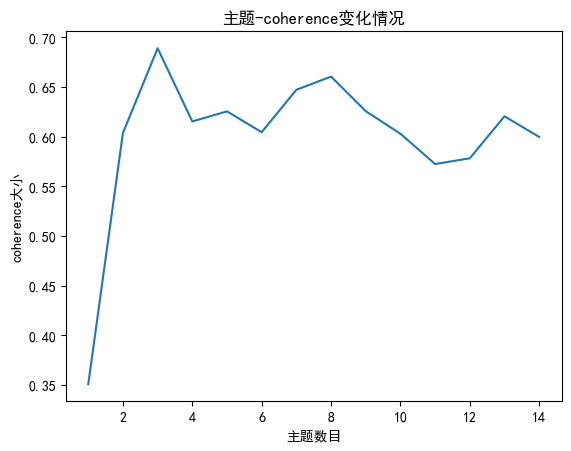

In [23]:
# 绘制主题-coherence曲线，选择最佳主题数
x = range(1,15)
# z = [perplexity(i) for i in x]  #如果想用困惑度就选这个
y = [coherence(i) for i in x]
plt.plot(x, y)
plt.xlabel('主题数目')
plt.ylabel('coherence大小')
plt.rcParams['font.sans-serif']=['SimHei']
matplotlib.rcParams['axes.unicode_minus']=False
plt.title('主题-coherence变化情况')
plt.show()

In [1]:
# 结果输出与可视化
# 通过上述主题评估，我们发现可以选择3作为主题个数，接下来我们可以再跑一次模型，设定主题数为5，并输出每个文档最有可能对应的主题

from gensim.models import LdaModel
import pandas as pd
from gensim.corpora import Dictionary
from gensim import corpora, models
import csv
import gensim
from gensim import corpora
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import warnings
warnings.filterwarnings('ignore')  # To ignore all warnings that arise here to enhance clarity
 
from gensim.models.coherencemodel import CoherenceModel
from gensim.models.ldamodel import LdaModel

C:\Users\Jessie\AppData\Roaming\Python\Python39\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Jessie\AppData\Roaming\Python\Python39\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# 先将文档转化为一个二元列表，其中每个子列表代表一条评论：
PATH = "./review/cutword.csv"

file_object = open(PATH, encoding = 'utf-8', errors = 'ignore').read().split('\n')  #一行行的读取内容

data_set=[]  #建立存储分词的列表
for i in range(len(file_object)):
    result=[]
    seg_list = file_object[i].split()
    for w in seg_list :  #读取每一行分词
        result.append(w)
    data_set.append(result)
print(data_set)

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [3]:
# 构建词典，语料向量化表示
dictionary = corpora.Dictionary(data_set)  # 构建词典
corpus = [dictionary.doc2bow(text) for text in data_set]  #表示为第几个单词出现了几次

In [4]:
# 一般用来评价LDA主题模型的指标有困惑度（perplexity）和主题一致性（coherence），困惑度越低或者一致性越高说明模型越好。
# 一些研究表明perplexity并不是一个好的指标，所以一般我用coherence来评价模型并选择最优主题，但下面代码两种方法我都用了。

#计算困惑度
def perplexity(num_topics):
    ldamodel = LdaModel(corpus, num_topics=num_topics, id2word = dictionary, passes=30)
    print(ldamodel.print_topics(num_topics=num_topics, num_words=15))
    print(ldamodel.log_perplexity(corpus))
    return ldamodel.log_perplexity(corpus)

#计算coherence
def coherence(num_topics):
    ldamodel = LdaModel(corpus, num_topics=num_topics, id2word = dictionary, passes=30, random_state = 1)
    print(ldamodel.print_topics(num_topics=num_topics, num_words=10))
    ldacm = CoherenceModel(model=ldamodel, texts=data_set, dictionary=dictionary, coherence='c_v')
    print(ldacm.get_coherence())
    return ldacm.get_coherence()

In [5]:
lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=3, passes = 30, random_state=1)
topic_list=lda.print_topics()
print(topic_list)

[(0, '0.018*"流畅" + 0.017*"体验" + 0.015*"性能" + 0.011*"屏幕" + 0.011*"办公" + 0.010*"续航" + 0.009*"电脑" + 0.009*"功能" + 0.009*"款" + 0.009*"学习"'), (1, '0.024*"买" + 0.020*"质量" + 0.019*"不错" + 0.018*"物流" + 0.016*"价格" + 0.015*"满意" + 0.015*"喜欢" + 0.012*"很快" + 0.012*"性价比" + 0.012*"快"'), (2, '0.051*"屏幕" + 0.034*"运行" + 0.033*"效果" + 0.032*"速度" + 0.032*"外观" + 0.030*"轻薄" + 0.024*"材质" + 0.020*"不错" + 0.018*"流畅" + 0.017*"音质"')]


In [6]:
result_list =[]
for i in lda.get_document_topics(corpus)[:]:
    listj=[]
    for j in i:
        listj.append(j[1])
    bz=listj.index(max(listj))
    result_list.append(i[bz][0])
print(result_list)

[1, 1, 0, 0, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 0, 2, 0, 2, 2, 1, 2, 0, 1, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 1, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 1, 2, 1, 1, 2, 2, 2, 0, 1, 1, 0, 2, 0, 1, 0, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 2, 0, 0, 0, 1, 2, 2, 1, 2, 0, 1, 1, 1, 0, 1, 2, 2, 0, 2, 1, 0, 2, 0, 0, 2, 0, 1, 2, 1, 1, 2, 2, 2, 2, 2, 2, 1, 0, 2, 2, 1, 2, 2, 0, 2, 0, 1, 0, 2, 2, 2, 2, 0, 0, 1, 1, 2, 2, 0, 2, 1, 1, 2, 2, 2, 0, 2, 2, 2, 2, 1, 2, 0, 0, 2, 0, 2, 1, 2, 1, 0, 2, 0, 0, 1, 1, 2, 2, 2, 2, 0, 0, 2, 1, 2, 1, 0, 0, 2, 2, 1, 1, 1, 2, 0, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 0, 2, 2, 2, 2, 1, 1, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1, 0, 2, 1, 2, 0, 0, 2, 0, 0, 2, 2, 1, 2, 2, 2, 1, 1, 0, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 0, 0, 2, 1, 2, 1, 2, 2, 2, 2, 2, 1, 2, 0, 2, 2, 0, 1, 2, 2, 0, 1, 2, 1, 1, 0, 2, 2, 2, 0, 2, 1, 2, 2, 0, 2, 0, 1, 1, 1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 1, 1, 2, 0, 0, 2, 0, 1, 1, 1, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 2, 0, 2, 0, 2, 2, 2, 2, 0, 1, 1, 2, 1, 0, 1, 1, 1, 1, 2, 2, 0, 

In [7]:
# 同时我们可以用pyLDAvis对LDA模型结果进行可视化
import pyLDAvis.gensim
pyLDAvis.enable_notebook()
data = pyLDAvis.gensim.prepare(lda, corpus, dictionary)
pyLDAvis.save_html(data, './output/topic.html')

# 情感词典标注

In [23]:
"""
# 加载数据
#txt_path = './content.txt'  # 你的txt文件的路径，绝对路径和相对路径都可，我这里是相对路径

comment_list = []
with open(txt_path, 'r', encoding='utf-8')as f:
    for i in f.readlines():
        i = i.replace('\n','')
        comment_list.append(i)


import jieba
import paddle
# 定义分词函数
def chinese_word_cut(mytext):
    #jieba.load_userdict('自定义词典.txt')  # 这里你可以添加jieba库识别不了的网络新词，避免将一些新词拆开
    jieba.initialize()  # 初始化jieba
    
    # 文本预处理 ：去除一些无用的字符只提取出中文出来
    new_data = re.findall('[\u4e00-\u9fa5]+', mytext, re.S)
    new_data = " ".join(new_data)
    
    # 文本分词
    # 安装了PaddlePaddle深度学习框架
    # jieba.enable_paddle()   已经停用
    paddle.enable_static()
    seg_list_exact = jieba.cut(mytext, use_paddle=True)
    result_list = []
    
    # 读取停用词库
    with open('stopwords.txt', encoding='utf-8') as f: # 可根据需要打开停用词库，然后加上不想显示的词语
        con = f.readlines()
        stop_words = set()
        for i in con:
            i = i.replace("\n", "")   # 去掉读取每一行数据的\n
            stop_words.add(i)

    # 去除停用词
    for word in seg_list_exact:
        if word not in stop_words:
            result_list.append(word)      
    return result_list

reviews['评论词'] = reviews['评论'].apply(chinese_word_cut)


# 保存分词结果
save_path = '分词后的数据.txt'  # 要保存的分词文件的路径
with open(save_path,'a',encoding='utf-8')as f:
    for comment in reviews['评论']:
        cutted_comment = ' '.join(chinese_word_cut(comment))
        if cutted_comment:
            f.write(cutted_comment)
            f.write('\n')
"""

'\n# 加载数据\n#txt_path = \'./content.txt\'  # 你的txt文件的路径，绝对路径和相对路径都可，我这里是相对路径\n\ncomment_list = []\nwith open(txt_path, \'r\', encoding=\'utf-8\')as f:\n    for i in f.readlines():\n        i = i.replace(\'\n\',\'\')\n        comment_list.append(i)\n\n\nimport jieba\nimport paddle\n# 定义分词函数\ndef chinese_word_cut(mytext):\n    #jieba.load_userdict(\'自定义词典.txt\')  # 这里你可以添加jieba库识别不了的网络新词，避免将一些新词拆开\n    jieba.initialize()  # 初始化jieba\n    \n    # 文本预处理 ：去除一些无用的字符只提取出中文出来\n    new_data = re.findall(\'[一-龥]+\', mytext, re.S)\n    new_data = " ".join(new_data)\n    \n    # 文本分词\n    # 安装了PaddlePaddle深度学习框架\n    # jieba.enable_paddle()   已经停用\n    paddle.enable_static()\n    seg_list_exact = jieba.cut(mytext, use_paddle=True)\n    result_list = []\n    \n    # 读取停用词库\n    with open(\'stopwords.txt\', encoding=\'utf-8\') as f: # 可根据需要打开停用词库，然后加上不想显示的词语\n        con = f.readlines()\n        stop_words = set()\n        for i in con:\n            i = i.replace("\n", "")   # 去掉读取每一行数据的\n\n         

In [20]:
# 将词语转为数据框形式，一列是词，一列是词语所在的句子ID（index_content），一列是词语在该句子的位置（index_word）
n_word = seg_word.apply(lambda x: len(x))  # 每一评论中词的个数，组成列表。
n_content = [[x+1]*y for x,y in zip(list(seg_word.index), list(n_word))] # 将评论索引和评论的词语数量一一配对，为每个分词构造所在评论的id
# [x+1]*y：生成一个长度为 y 的列表，列表中的每个元素是 x+1
# n_content为嵌套列表
index_content = sum(n_content, [])  # 将嵌套的列表展开为扁平列表，作为词所在评论的id。[]是初始值

In [21]:
# 词性标注
seg_word = sum(seg_word, [])
word = [x[0] for x in seg_word]  # 词
nature = [x[1] for x in seg_word]  # 词性

In [23]:
product = [[x]*y for x,y in zip(list(reviews['商品名称']), list(n_word))]
product = sum(product, [])  # 商品名称

content_type = [[x]*y for x,y in zip(list(reviews['评价星级']), list(n_word))]
content_type = sum(content_type, []) #评论类型

result = pd.DataFrame({"index_content":index_content, 
                       "product":product,
                       "content_type": content_type,
                       "word":word,
                       "nature":nature}) # 得到分词、词性标注后的结果
result

,index_content,product,content_type,word,nature
0,1,MatePad Pro 11,pos,支持,v
1,1,MatePad Pro 11,pos,国产,n
2,1,MatePad Pro 11,pos,，,x
3,1,MatePad Pro 11,pos,孩子,n
4,1,MatePad Pro 11,pos,点名,v
...,...,...,...,...,...
907859,16556,小米Redmi Pad SE,pos,真的,d
907860,16556,小米Redmi Pad SE,pos,是,v
907861,16556,小米Redmi Pad SE,pos,物超所值,i
907862,16556,小米Redmi Pad SE,pos,！,x


In [24]:
# 删除标点符号
result = result[result['nature'] != 'x']  # x表示标点符号
result

,index_content,product,content_type,word,nature
0,1,MatePad Pro 11,pos,支持,v
1,1,MatePad Pro 11,pos,国产,n
3,1,MatePad Pro 11,pos,孩子,n
4,1,MatePad Pro 11,pos,点名,v
5,1,MatePad Pro 11,pos,要,v
...,...,...,...,...,...
907856,16556,小米Redmi Pad SE,pos,非常,d
907857,16556,小米Redmi Pad SE,pos,合理,vn
907859,16556,小米Redmi Pad SE,pos,真的,d
907860,16556,小米Redmi Pad SE,pos,是,v


In [25]:
# 去除停用词
stop_path = open(r'./stopwords.txt', 'r',encoding='UTF-8') # 导入停用词词典,'r'只读
stop = stop_path.readlines() # 读取行并作为字符串列表返回
stop = [x.replace('\n', '') for x in stop] # 用空值替换\n换行符
word = list(set(word) - set(stop)) # 首先构造词和停用词的无序无重复set集合，然后在词的set中去除停用词的set
result = result[result['word'].isin(word)] # 从词中去除停用词，并更新result表格
result

,index_content,product,content_type,word,nature
0,1,MatePad Pro 11,pos,支持,v
1,1,MatePad Pro 11,pos,国产,n
3,1,MatePad Pro 11,pos,孩子,n
4,1,MatePad Pro 11,pos,点名,v
8,1,MatePad Pro 11,pos,家里,s
...,...,...,...,...,...
907845,16556,小米Redmi Pad SE,pos,性能,n
907849,16556,小米Redmi Pad SE,pos,易于,v
907854,16556,小米Redmi Pad SE,pos,价格,n
907859,16556,小米Redmi Pad SE,pos,真的,d


In [26]:
# 构造各词在对应评论的位置列（添加到最后一列）
n_word = list(result.groupby(by = ['index_content'])['index_content'].count()) # 对去除停用词后的result重新计数
index_word = [list(np.arange(0, y)) for y in n_word] # 为每条评论中的词指定在该评论中的id
index_word = sum(index_word, [])  # 合并成一列

In [27]:
# 合并评论id，评论中词的id，词，词性，评论类型
result['index_word'] = index_word # 添加index_word一列到原表格的最右一列
result

C:\Users\Jessie\AppData\Local\Temp\ipykernel_7792\999823848.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result['index_word'] = index_word # 添加index_word一列到原表格的最右一列


,index_content,product,content_type,word,nature,index_word
0,1,MatePad Pro 11,pos,支持,v,0
1,1,MatePad Pro 11,pos,国产,n,1
3,1,MatePad Pro 11,pos,孩子,n,2
4,1,MatePad Pro 11,pos,点名,v,3
8,1,MatePad Pro 11,pos,家里,s,4
...,...,...,...,...,...,...
907845,16556,小米Redmi Pad SE,pos,性能,n,7
907849,16556,小米Redmi Pad SE,pos,易于,v,8
907854,16556,小米Redmi Pad SE,pos,价格,n,9
907859,16556,小米Redmi Pad SE,pos,真的,d,10


In [28]:
# 重新编号
result = result.reset_index(drop=True)
result

,index_content,product,content_type,word,nature,index_word
0,1,MatePad Pro 11,pos,支持,v,0
1,1,MatePad Pro 11,pos,国产,n,1
2,1,MatePad Pro 11,pos,孩子,n,2
3,1,MatePad Pro 11,pos,点名,v,3
4,1,MatePad Pro 11,pos,家里,s,4
...,...,...,...,...,...,...
421054,16556,小米Redmi Pad SE,pos,性能,n,7
421055,16556,小米Redmi Pad SE,pos,易于,v,8
421056,16556,小米Redmi Pad SE,pos,价格,n,9
421057,16556,小米Redmi Pad SE,pos,真的,d,10


In [29]:
word_dict = {}
for w in result["word"]:
    if w in word_dict.keys():
        word_dict[w] += 1
    else:
        word_dict[w] = 1
# 打印出根据value排序后的键值对
sorted_word_dict = sorted(word_dict.items(),  key=lambda d: d[1], reverse=True)
sorted_word_dict

[('屏幕', 9583),
 ('速度', 6736),
 ('不错', 6255),
 ('运行', 6209),
 ('效果', 5948),
 ('外观', 5600),
 ('流畅', 5487),
 ('轻薄', 5431),
 ('买', 4301),
 ('高', 3988),
 ('快', 3743),
 ('材质', 3730),
 ('清晰', 3403),
 ('喜欢', 3357),
 ('体验', 3309),
 ('很快', 3086),
 ('真的', 2966),
 ('性价比', 2866),
 ('音质', 2779),
 ('质量', 2773),
 ('满意', 2730),
 ('程度', 2624),
 ('物流', 2529),
 ('价格', 2300),
 ('特别', 2296),
 ('学习', 2134),
 ('系统', 2111),
 ('音效', 2101),
 ('性能', 2064),
 ('视频', 2015),
 ('值得', 1984),
 ('购买', 1877),
 ('手感', 1853),
 ('款', 1844),
 ('感觉', 1834),
 ('办公', 1754),
 ('产品', 1695),
 ('推荐', 1681),
 ('质感', 1675),
 ('电脑', 1659),
 ('收到', 1642),
 ('包装', 1625),
 ('好看', 1589),
 ('舒服', 1519),
 ('购物', 1483),
 ('续航', 1422),
 ('太', 1382),
 ('手机', 1363),
 ('孩子', 1342),
 ('薄', 1311),
 ('功能', 1296),
 ('挺', 1269),
 ('超级', 1250),
 ('出色', 1213),
 ('棒', 1172),
 ('一款', 1167),
 ('显示', 1165),
 ('特色', 1158),
 ('操作', 1150),
 ('无论是', 1137),
 ('卡顿', 1126),
 ('发货', 1120),
 ('机身', 1107),
 ('服务', 1091),
 ('颜色', 1053),
 ('没', 1048),
 ('电池', 1044),
 (

In [30]:
ind = result[['n' in x for x in result['nature']]]['index_content'].unique() # 提取名词所在评论的id。unique()是Pandas中的一个函数，用于获取Series或DataFrame中的唯一值。它返回一个包含Series或DataFrame中唯一值的数组，按照它们在原始数据中的出现顺序排列。
result = result[[x in ind for x in result['index_content']]] # 保留包含名词的评论
result

,index_content,product,content_type,word,nature,index_word
0,1,MatePad Pro 11,pos,支持,v,0
1,1,MatePad Pro 11,pos,国产,n,1
2,1,MatePad Pro 11,pos,孩子,n,2
3,1,MatePad Pro 11,pos,点名,v,3
4,1,MatePad Pro 11,pos,家里,s,4
...,...,...,...,...,...,...
421054,16556,小米Redmi Pad SE,pos,性能,n,7
421055,16556,小米Redmi Pad SE,pos,易于,v,8
421056,16556,小米Redmi Pad SE,pos,价格,n,9
421057,16556,小米Redmi Pad SE,pos,真的,d,10


# STEP 5 绘制词云

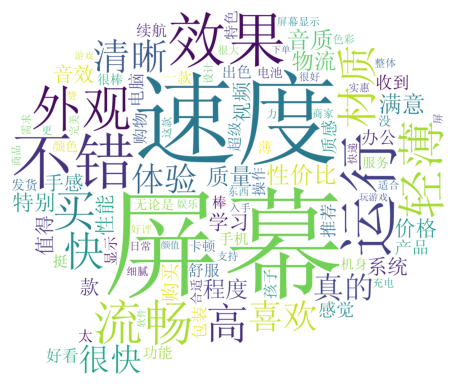

In [31]:
from wordcloud import WordCloud
from matplotlib import pyplot as plt

plt.rcParams['font.sans-serif'] = 'Source Han Sans CN'  # 设置中文显示
plt.rcParams['axes.unicode_minus'] = False # 正确显示坐标轴正负号

frequencies = result.groupby(by=['word'])['word'].count() # 统计每个词出现的次数
frequencies = frequencies.sort_values(ascending=False) # 降序排序
backgroud_Image = plt.imread('./data/pl.jpg') # 导入背景图片
wordcloud = WordCloud(font_path="simsun.ttf", # 指定字体：黑体
                      max_words=100, # 绘制前100个词
                      background_color='white',
                      mask=backgroud_Image)
my_wordcloud = wordcloud.fit_words(frequencies) # 按词频绘制词云
plt.imshow(my_wordcloud) # 画图
plt.axis('off') # 是否显示坐标轴下标
plt.show()

In [32]:
result.to_csv(r'./tmp/word.csv', index = False, encoding = 'utf-8')

# STEP 6 匹配情感词

In [33]:
word = pd.read_csv(r'./tmp/word.csv')
word

,index_content,product,content_type,word,nature,index_word
0,1,MatePad Pro 11,pos,支持,v,0
1,1,MatePad Pro 11,pos,国产,n,1
2,1,MatePad Pro 11,pos,孩子,n,2
3,1,MatePad Pro 11,pos,点名,v,3
4,1,MatePad Pro 11,pos,家里,s,4
...,...,...,...,...,...,...
420570,16556,小米Redmi Pad SE,pos,性能,n,7
420571,16556,小米Redmi Pad SE,pos,易于,v,8
420572,16556,小米Redmi Pad SE,pos,价格,n,9
420573,16556,小米Redmi Pad SE,pos,真的,d,10


In [34]:
# 读入正面、负面情感评价词
pos_comment = pd.read_csv("./data/正面评价词语（中文）.txt", header=None,sep="/n", encoding = 'utf-8', engine='python') # header=none是一种文件读取模式,用于读取没有列标题的文件。sep=’ ‘： 表示当输入多个打印的值时，各个值之间分割方式，默认空格，可以自定义，/n为换行符。
neg_comment = pd.read_csv("./data/负面评价词语（中文）.txt", header=None,sep="/n", encoding = 'utf-8', engine='python')
pos_emotion = pd.read_csv("./data/正面情感词语（中文）.txt", header=None,sep="/n", encoding = 'utf-8', engine='python')
neg_emotion = pd.read_csv("./data/负面情感词语（中文）.txt", header=None,sep="/n", encoding = 'utf-8', engine='python') 

In [35]:
# 合并情感词与评价词
positive = set(pos_comment.iloc[:,0])|set(pos_emotion.iloc[:,0])
negative = set(neg_comment.iloc[:,0])|set(neg_emotion.iloc[:,0])
intersection = positive & negative  # 正负面情感词表中相同的词语
positive = list(positive - intersection) # 剔除正负面情感词中共同含有的有争议词
negative = list(negative - intersection)

positive = pd.DataFrame({"word":positive,
                         "weight":[1]*len(positive)})
negative = pd.DataFrame({"word":negative,
                         "weight":[-1]*len(negative)}) 

posneg = pd.concat([positive,negative]) # pd.concat拼接函数。

posneg

,word,weight
0,上照,1
1,浑身是胆,1
2,落落大方,1
3,承,1
4,自然,1
...,...,...
4232,沉重,-1
4233,毛头毛脑,-1
4234,桀骜不驯,-1
4235,狡,-1


In [36]:
#  将分词结果与正负面情感词表合并，定位情感词
data_posneg = posneg.merge(word, left_on = 'word', right_on = 'word', how = 'right') # how: 合并方式，可选值包括"inner"、"outer"、"left"和"right"，分别对应内连接、外连接、左连接和右连接。默认为"inner"。
data_posneg = data_posneg.sort_values(by = ['index_content','index_word'])
data_posneg

,word,weight,index_content,product,content_type,nature,index_word
0,支持,1.0,1,MatePad Pro 11,pos,v,0
1,国产,NaN,1,MatePad Pro 11,pos,n,1
2,孩子,NaN,1,MatePad Pro 11,pos,n,2
3,点名,NaN,1,MatePad Pro 11,pos,v,3
4,家里,NaN,1,MatePad Pro 11,pos,s,4
...,...,...,...,...,...,...,...
420570,性能,NaN,16556,小米Redmi Pad SE,pos,n,7
420571,易于,NaN,16556,小米Redmi Pad SE,pos,v,8
420572,价格,NaN,16556,小米Redmi Pad SE,pos,n,9
420573,真的,NaN,16556,小米Redmi Pad SE,pos,d,10


# STEP 7 修正情感倾向

In [37]:
# 根据情感词前时候有否定词或双层否定词对情感值进行修正
# 载入否定词表
notdict = pd.read_csv("./data/not.csv")
notdict

,term
0,不
1,没
2,无
3,非
4,莫
5,弗
6,毋
7,勿
8,未
9,否


In [38]:
# 处理否定修饰词
data_posneg['amend_weight'] = data_posneg['weight']  # 构造新列，作为经过否定词修正后的情感值
data_posneg['id'] = np.arange(0, len(data_posneg))
only_inclination = data_posneg.dropna()  # 只保留有情感值的词语。.dropna() 是 pandas 库中 DataFrame 和 Series 对象的一个方法，用于删除包含缺失值的行或列
only_inclination.index = np.arange(0, len(only_inclination))
index = only_inclination['id']

for i in np.arange(0, len(only_inclination)):
    review = data_posneg[data_posneg['index_content'] == only_inclination['index_content'][i]]  # 提取第i个情感词所在的评论
    review.index = np.arange(0, len(review))
    affective = only_inclination['index_word'][i]  # 第i个情感值在该评论中的位置
    if affective == 1:
        ne = sum([i in notdict['term'] for i in review['word'][affective - 1]]) # 当目标分词位于第二位，则考察第一位的否定性。
        if ne == 1: # 当前面有1个否定词，则更改分数为相反数。
            data_posneg['amend_weight'][index[i]] = - data_posneg['weight'][index[i]]          
    elif affective > 1: #当目标分词位于第三位及之后，则考察前两位的否定性。
        ne = sum([i in notdict['term'] for i in review['word'][[affective - 1, 
                  affective - 2]]])
        if ne == 1:  # 当前面两个分词中有1个否定词，则更改分数为相反数。
            data_posneg['amend_weight'][index[i]] = - data_posneg['weight'][index[i]]


In [39]:
# 更新只保留情感值的数据
only_inclination = only_inclination.dropna()

In [40]:
# 计算每条评论的情感值
emotional_value = only_inclination.groupby(['index_content'],as_index=False)['word','amend_weight'].sum() 
# as_index: 分组结果默认将分组列的值作为索引，如果按单列分组，结果默认是单索引，如果按多列分组，结果默认是多重索引。将as_index设置为False可以重置索引（0,1...）。

In [41]:
# 去除情感值为0的评论
emotional_value = emotional_value[emotional_value['amend_weight'] != 0]
emotional_value

,index_content,amend_weight
0,1,9.0
1,2,12.0
2,3,4.0
3,4,2.0
4,5,2.0
...,...,...
16108,16551,3.0
16109,16552,2.0
16111,16554,2.0
16112,16555,1.0


# STEP 8 查看情感分析效果

In [42]:
# 给情感值大于0的赋予评论类型（content_type）为pos,小于0的为neg
emotional_value['a_type'] = ''
emotional_value['a_type'][emotional_value['amend_weight'] > 0] = 'pos'
emotional_value['a_type'][emotional_value['amend_weight'] < 0] = 'neg'
emotional_value

C:\Users\Jessie\AppData\Local\Temp\ipykernel_7792\1993566115.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emotional_value['a_type'][emotional_value['amend_weight'] > 0] = 'pos'
C:\Users\Jessie\AppData\Local\Temp\ipykernel_7792\1993566115.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emotional_value['a_type'][emotional_value['amend_weight'] < 0] = 'neg'


,index_content,amend_weight,a_type
0,1,9.0,pos
1,2,12.0,pos
2,3,4.0,pos
3,4,2.0,pos
4,5,2.0,pos
...,...,...,...
16108,16551,3.0,pos
16109,16552,2.0,pos
16111,16554,2.0,pos
16112,16555,1.0,pos


In [43]:
# 查看情感分析结果
result = emotional_value.merge(word, 
                               left_on = 'index_content', 
                               right_on = 'index_content',
                               how = 'left')
result = result[['index_content','content_type', 'a_type']].drop_duplicates() 
result

,index_content,content_type,a_type
0,1,pos,pos
24,2,pos,pos
97,3,pos,pos
114,4,pos,pos
130,5,pos,pos
...,...,...,...
403985,16551,pos,pos
403999,16552,pos,pos
404014,16554,pos,pos
404032,16555,pos,pos


In [44]:
confusion_matrix = pd.crosstab(result['content_type'], result['a_type'], margins=True)  # 制作混淆矩阵
confusion_matrix

a_type,neg,pos,All
content_type,,,
neg,51,91,142
pos,413,14902,15315
All,464,14993,15457


In [45]:
print('基于词表的情感分析的准确率为：',(confusion_matrix.iat[0,0] + confusion_matrix.iat[1,1])/confusion_matrix.iat[2,2])

基于词表的情感分析的准确率为： 0.9673934139871903


In [46]:
# 提取正负面评论信息
ind_pos = list(emotional_value[emotional_value['a_type'] == 'pos']['index_content']) # 提取正向评论id
ind_neg = list(emotional_value[emotional_value['a_type'] == 'neg']['index_content']) # 提取负向评论id
posdata = word[[i in ind_pos for i in word['index_content']]] # 提取正向评论所包含的分词
negdata = word[[i in ind_neg for i in word['index_content']]] # 提取负向评论所包含的分词

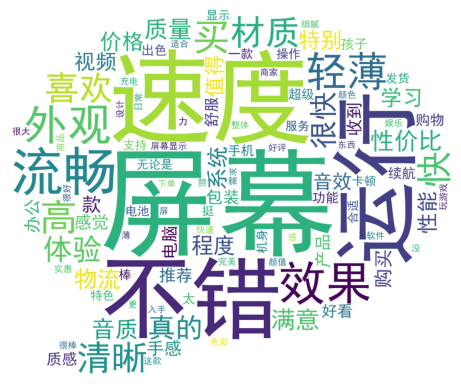

In [47]:
# 绘制词云

# 正面情感词词云
freq_pos = posdata.groupby(by = ['word'])['word'].count() # 计算个分词出现次数
freq_pos = freq_pos.sort_values(ascending = False) # 降序排列
backgroud_Image=plt.imread('./data/pl.jpg')
wordcloud = WordCloud(font_path="./simhei.ttf",
                      max_words=100,
                      background_color='white',
                      mask=backgroud_Image)
pos_wordcloud = wordcloud.fit_words(freq_pos)
plt.imshow(pos_wordcloud)
plt.axis('off') 
plt.show()

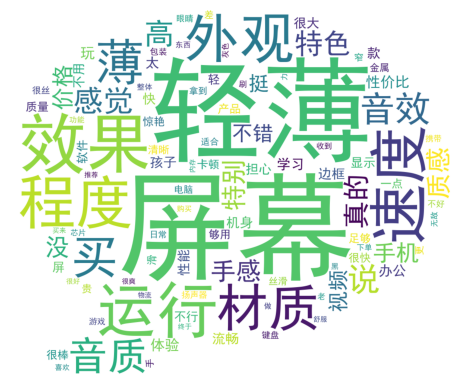

In [48]:
# 负面情感词词云
freq_neg = negdata.groupby(by = ['word'])['word'].count()
freq_neg = freq_neg.sort_values(ascending = False)
neg_wordcloud = wordcloud.fit_words(freq_neg)
plt.imshow(neg_wordcloud)
plt.axis('off') 
plt.show()

In [59]:
# 将结果写出,每条评论作为一行
posdata.to_csv(r'./tmp/posdata_pad.csv', index = False, encoding = 'utf-8')
negdata.to_csv(r'./tmp/negdata_pad.csv', index = False, encoding = 'utf-8')

In [50]:
import itertools
from gensim import corpora, models

# 建立词典
pos_dict = corpora.Dictionary([[i] for i in posdata['word']])  # 正面评论中的分词组成正面词典
neg_dict = corpora.Dictionary([[i] for i in negdata['word']])  # 负面评论中的分词组成负面词典

In [51]:
# 建立语料库
pos_corpus = [pos_dict.doc2bow(j) for j in [[i] for i in posdata['word']]]  # Doc2bow是封装于Gensim中的⽅法，主要是实现bow模型，bow模型（词袋）模型使⽤⼀组单词（⽆序）来表⽰⼀个句⼦。doc2bow 将字典转换为向量形式。
neg_corpus = [neg_dict.doc2bow(j) for j in [[i] for i in negdata['word']]]

# STEP 10 主题数寻优

In [53]:
# 构造余弦相似度函数
def cos(vector1, vector2):  
    dot_product = 0.0;  
    normA = 0.0;  
    normB = 0.0;  
    for a,b in zip(vector1, vector2): 
        dot_product += a*b  
        normA += a**2  
        normB += b**2  
    if normA == 0.0 or normB==0.0:  
        return(None)  
    else:  
        return(dot_product / ((normA*normB)**0.5))   

In [54]:
# 构造主题平均余弦计算函数
def lda_k(x_corpus, x_dict):  
    
    # 初始化平均余弦相似度
    mean_similarity = []
    mean_similarity.append(1) # append() 函数可以向列表末尾添加元素。
    
    # 循环生成主题并计算主题间相似度
    for i in np.arange(2,11):
        lda = models.LdaModel(x_corpus, num_topics = i, id2word = x_dict)  # LDA模型训练
        for j in np.arange(i): # 记录每一种主题划分形式的分词情况。
            term = lda.show_topics(num_words = 50) # num_words选取每个主题中频数最大的前50个分词。
            
        # 提取各主题词
        top_word = []
        for k in np.arange(i):
            top_word.append([''.join(re.findall('"(.*)"',i)) for i in term[k][1].split('+')])  # 列出所有词
            # join函数：使用空格连接序列中的元素并生成新的字符串。
            # re.findall函数：.*表示将"(和)"之间的内容截取出来。
            # .split函数：制定按+对字符串进行切割。
           
        # 构造词频向量
        word = sum(top_word,[])  # 列出所有的词及其频数   
        unique_word = set(word)  # 去除重复的词
        
        # 构造主题词列表，行表示主题号，列表示各主题词
        mat = []
        for j in np.arange(i):
            top_w = top_word[j]
            mat.append(tuple([top_w.count(k) for k in unique_word]))  # 去重后，计算各主题下各分词频数。tuple函数：将列表、区间等转换为元组。
            
        p = list(itertools.permutations(list(np.arange(i)),2)) # itertools.permutations函数：实现排列组合，将list中的数据取出2个进行排列组合。
        l = len(p)
        top_similarity = [0]
        for w in np.arange(l): # 计算主题数i下的平均余弦相似度，需将i个主题两两分别计算，最后求平均。
            vector1 = mat[p[w][0]]
            vector2 = mat[p[w][1]]
            top_similarity.append(cos(vector1, vector2))
            
        # 计算平均余弦相似度
        mean_similarity.append(sum(top_similarity)/l)
    return(mean_similarity)

In [55]:
# 计算主题平均余弦相似度
pos_k = lda_k(pos_corpus, pos_dict)
neg_k = lda_k(neg_corpus, neg_dict)   
print(pos_k)
print(neg_k)

[2025-04-13 17:12:13,720] [ WARNING] ldamodel.py:958 - too few updates, training might not converge; consider increasing the number of passes or iterations to improve accuracy
[2025-04-13 17:12:14,787] [ WARNING] ldamodel.py:958 - too few updates, training might not converge; consider increasing the number of passes or iterations to improve accuracy
[2025-04-13 17:12:16,258] [ WARNING] ldamodel.py:958 - too few updates, training might not converge; consider increasing the number of passes or iterations to improve accuracy
[2025-04-13 17:12:17,258] [ WARNING] ldamodel.py:958 - too few updates, training might not converge; consider increasing the number of passes or iterations to improve accuracy
[2025-04-13 17:12:18,162] [ WARNING] ldamodel.py:958 - too few updates, training might not converge; consider increasing the number of passes or iterations to improve accuracy
[2025-04-13 17:12:19,019] [ WARNING] ldamodel.py:958 - too few updates, training might not converge; consider increasing

[1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[1, 0.02, 0.0, 0.0, 0.0, 0.004, 0.0047619047619047615, 0.007142857142857143, 0.015000000000000006, 0.02933333333333335]


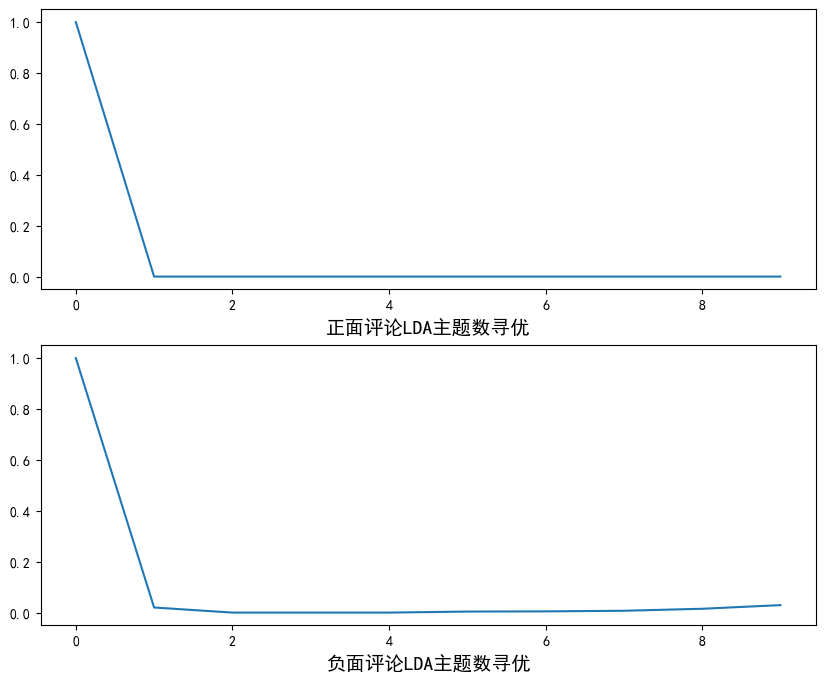

In [56]:
# 绘制主题平均余弦相似度图形
from matplotlib.font_manager import FontProperties  

font = FontProperties(size=14) # 字号
fig = plt.figure(figsize=(10,8))

# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

ax1 = fig.add_subplot(211) # 子图。2行1列，第1个图。
ax1.plot(pos_k)
ax1.set_xlabel('正面评论LDA主题数寻优', fontproperties=font)

ax2 = fig.add_subplot(212) # 子图。2行1列，第2个图。
ax2.plot(neg_k)
ax2.set_xlabel('负面评论LDA主题数寻优', fontproperties=font)

plt.show()

# STEP11 LDA主题分析

In [58]:
# LDA主题分析
pos_lda = models.LdaModel(pos_corpus, num_topics = 1, id2word = pos_dict)  # 从上图中读出，取1个主题数，能兼顾主题数目最少、余弦相似度最低。
neg_lda = models.LdaModel(neg_corpus, num_topics = 2, id2word = neg_dict)  # 从上图中读出，取2个主题数，能兼顾主题数目最少、余弦相似度最低。


print(pos_lda.print_topics(num_words=10))
print(neg_lda.print_topics(num_words=10))

[2025-04-13 17:15:15,021] [ WARNING] ldamodel.py:958 - too few updates, training might not converge; consider increasing the number of passes or iterations to improve accuracy


[(0, '0.020*"屏幕" + 0.014*"速度" + 0.013*"不错" + 0.013*"运行" + 0.012*"外观" + 0.012*"流畅" + 0.012*"效果" + 0.011*"轻薄" + 0.010*"买" + 0.010*"高"')]
[(0, '0.047*"轻薄" + 0.037*"效果" + 0.029*"外观" + 0.026*"材质" + 0.026*"买" + 0.018*"音质" + 0.018*"薄" + 0.014*"音效" + 0.013*"感觉" + 0.013*"高"'), (1, '0.058*"屏幕" + 0.029*"速度" + 0.028*"运行" + 0.025*"程度" + 0.015*"说" + 0.010*"真的" + 0.009*"特色" + 0.009*"手机" + 0.008*"特别" + 0.008*"挺"')]


# STEP 5 TF-IDF

In [ ]:
# -*- coding: utf-8 -*-
from collections import defaultdict
import math
import operator
 
"""
函数说明:创建数据样本
Returns:
    dataset - 实验样本切分的词条
    classVec - 类别标签向量
"""
def loadDataSet():
    dataset = [ ['my', 'dog', 'has', 'flea', 'problems', 'help', 'please'],    # 切分的词条
                   ['maybe', 'not', 'take', 'him', 'to', 'dog', 'park', 'stupid'],
                   ['my', 'dalmation', 'is', 'so', 'cute', 'I', 'love', 'him'],
                   ['stop', 'posting', 'stupid', 'worthless', 'garbage'],
                   ['mr', 'licks', 'ate', 'my', 'steak', 'how', 'to', 'stop', 'him'],
                   ['quit', 'buying', 'worthless', 'dog', 'food', 'stupid'] ]
    classVec = [0, 1, 0, 1, 0, 1]  # 类别标签向量，1代表好，0代表不好
    return dataset, classVec
 
 
"""
函数说明：特征选择TF-IDF算法
Parameters:
     list_words:词列表
Returns:
     dict_feature_select:特征选择词字典
"""
def feature_select(list_words):
    #总词频统计
    doc_frequency=defaultdict(int)
    for word_list in list_words:
        for i in word_list:
            doc_frequency[i]+=1
 
    #计算每个词的TF值
    word_tf={}  #存储没个词的tf值
    for i in doc_frequency:
        word_tf[i]=doc_frequency[i]/sum(doc_frequency.values())
 
    #计算每个词的IDF值
    doc_num=len(list_words)
    word_idf={} #存储每个词的idf值
    word_doc=defaultdict(int) #存储包含该词的文档数
    for i in doc_frequency:
        for j in list_words:
            if i in j:
                word_doc[i]+=1
    for i in doc_frequency:
        word_idf[i]=math.log(doc_num/(word_doc[i]+1))
 
    #计算每个词的TF*IDF的值
    word_tf_idf={}
    for i in doc_frequency:
        word_tf_idf[i]=word_tf[i]*word_idf[i]
 
    # 对字典按值由大到小排序
    dict_feature_select=sorted(word_tf_idf.items(),key=operator.itemgetter(1),reverse=True)
    return dict_feature_select
 
if __name__=='__main__':
    data_list,label_list=loadDataSet() #加载数据
    features=feature_select(data_list) #所有词的TF-IDF值
    print(features)
    print(len(features))